# 1 · Rigid-body transforms

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Rudip1/learn-manipulator-control/blob/main/2_notebooks/exercises/01_rigid_body_transforms.ipynb)

Theory: [`1_theory/01_rigid_body_transforms.md`](../../1_theory/01_rigid_body_transforms.md) · notation:
[`00_notation.md`](../../1_theory/00_notation.md)

In [1]:
# Install the module when it is not importable yet (Colab, fresh environment).
import importlib.util
if importlib.util.find_spec("manipulator_control") is None:
    %pip install -q git+https://github.com/Rudip1/learn-manipulator-control
if importlib.util.find_spec("pinocchio") is None:
    %pip install -q pin

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pinocchio as pin

import manipulator_control as mc
from manipulator_control import plotting

plt.rcParams.update({"figure.dpi": 80, "axes.grid": True})
np.set_printoptions(precision=4, suppress=True)

## Recap

- A rotation ${}^{a}R_{b} \in SO(3)$ has the axes of $\{b\}$ as columns; $R^TR = I$, $\det R = 1$ (eq. 1.1).
- Angular velocity: $\dot R = [\omega]_\times R$ (eq. 1.4). Constant $\omega$ gives the exponential,
  evaluated in closed form by Rodrigues' formula (eq. 1.5); the logarithm (eq. 1.6) goes back.
- A pose is $T = \begin{bmatrix} R & p \\ 0 & 1\end{bmatrix} \in SE(3)$ with
  $T^{-1} = \begin{bmatrix} R^T & -R^Tp \\ 0 & 1\end{bmatrix}$ (eqs. 1.8–1.9).
- A twist $\mathcal V = (v, \omega)$ — linear part first — is the velocity of a rigid body,
  $[\mathcal V] = \dot T T^{-1}$ (eq. 1.10); $\mathrm{Ad}_T$ moves it between frames (eq. 1.11).
- Every displacement is a screw motion $\exp([\mathcal S]\theta)$ (eqs. 1.12–1.13).

All functions below run in C++ (`manipulator_control._core`).

## Rotations do not commute

Rotate by 90° about $x$ then $z$, or about $z$ then $x$. Multiplying on the right means "about the axes of the
current frame", so the two products are different orientations.

Rx Rz =
 [[ 0. -1.  0.]
 [ 0.  0. -1.]
 [ 1.  0.  0.]] 
Rz Rx =
 [[ 0. -0.  1.]
 [ 1.  0. -0.]
 [ 0.  1.  0.]]
both are rotations: True True


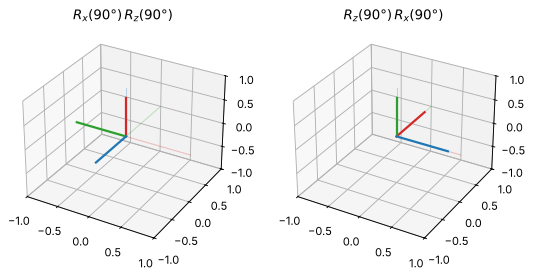

In [3]:
A = mc.rot_x(np.pi / 2) @ mc.rot_z(np.pi / 2)
B = mc.rot_z(np.pi / 2) @ mc.rot_x(np.pi / 2)
print("Rx Rz =\n", A, "\nRz Rx =\n", B)
print("both are rotations:", mc.is_rotation(A), mc.is_rotation(B))

fig = plt.figure(figsize=(8, 4))
for k, (R, title) in enumerate([(A, r"$R_x(90°)\,R_z(90°)$"), (B, r"$R_z(90°)\,R_x(90°)$")]):
    ax = fig.add_subplot(1, 2, k + 1, projection="3d")
    plotting.draw_frame(ax, np.eye(4), length=1.0, alpha=0.25, linewidth=1)
    plotting.draw_frame(ax, mc.make_transform(R, np.zeros(3)), length=0.8)
    ax.set_title(title)
    ax.set_xlim(-1, 1); ax.set_ylim(-1, 1); ax.set_zlim(-1, 1)
plt.show()

## Rodrigues' formula and the logarithm

`exp_so3(phi)` turns exponential coordinates (axis × angle) into a matrix; `log_so3` goes back. Pinocchio is
an independent implementation, so it serves as a reference.

In [4]:
rng = np.random.default_rng(1)
worst_exp, worst_log = 0.0, 0.0
for _ in range(1000):
    axis = rng.normal(size=3); axis /= np.linalg.norm(axis)
    phi = axis * rng.uniform(0, np.pi)
    R = mc.exp_so3(phi)
    worst_exp = max(worst_exp, np.abs(R - pin.exp3(phi)).max())
    worst_log = max(worst_log, np.abs(mc.log_so3(R) - phi).max())
print(f"max |exp_so3 - pinocchio.exp3| = {worst_exp:.1e}")
print(f"max |log_so3(exp_so3(phi)) - phi| = {worst_log:.1e}")

max |exp_so3 - pinocchio.exp3| = 8.9e-16
max |log_so3(exp_so3(phi)) - phi| = 1.3e-15


## Screw motion

Turning about a screw axis traces a helix (Figure 1.1 in the theory). Here the axis is vertical, passes
through $q = (0.5, 0, 0)$ and has pitch $h = 0.1$ m/rad.

S = [ 0.  -0.5  0.1  0.   0.   1. ]


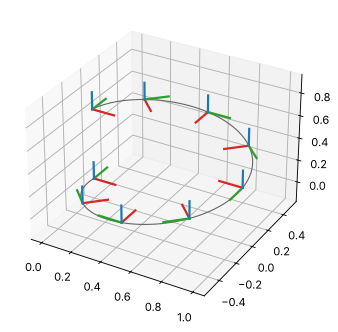

log(exp(S*1.2)) = [-0.   -0.6   0.12  0.    0.    1.2 ] 
S*1.2           = [ 0.   -0.6   0.12  0.    0.    1.2 ]


In [5]:
q, w, h = np.array([0.5, 0.0, 0.0]), np.array([0.0, 0.0, 1.0]), 0.1
S = mc.screw_axis(q, w, h)
print("S =", S)

fig = plt.figure(figsize=(5, 5))
ax = fig.add_subplot(projection="3d")
path = np.array([mc.exp_se3(S * t)[:3, 3] for t in np.linspace(0, 2 * np.pi, 300)])
ax.plot(*path.T, color="0.4", linewidth=1)
for t in np.linspace(0, 2 * np.pi, 9):
    plotting.draw_frame(ax, mc.exp_se3(S * t), length=0.15)
plotting.set_axes_equal(ax)
plt.show()

# The logarithm recovers the exponential coordinates.
xi = S * 1.2
print("log(exp(S*1.2)) =", mc.log_se3(mc.exp_se3(xi)), "\nS*1.2           =", xi)

## The same twist in two frames

A body spins about its own $z$ axis while its frame sits at ${}^{0}T_{b}$. In the body frame the twist is
$\mathcal V_b = (0, 0, 0, 0, 0, 1)$. The adjoint gives the same motion seen from $\{0\}$; differentiating
$T(t) = {}^{0}T_{b}\exp([\mathcal V_b]t)$ numerically gives the same answer.

In [6]:
T0b = mc.make_transform(mc.rotation_from_rpy([0.3, -0.2, 0.8]), [1.0, 0.5, 0.2])
V_b = np.array([0, 0, 0, 0, 0, 1.0])
V_0 = mc.adjoint(T0b) @ V_b

dt = 1e-6
T_dot = (T0b @ mc.exp_se3(V_b * dt) - T0b) / dt
V_0_numeric = mc.twist_vee(T_dot @ mc.inverse_transform(T0b))
print("Ad_T V_b          =", V_0)
print("from (dT/dt) T^-1 =", V_0_numeric)

Ad_T V_b          = [ 0.5366 -0.9203 -0.3819  0.0798 -0.342   0.9363]
from (dT/dt) T^-1 = [ 0.5366 -0.9203 -0.3819  0.0798 -0.342   0.9363]


## ✏️ Exercises

### ✏️ 1. Inverse of a transform

Write `inverse_T(T)` with eq. (1.9) — transpose and one matrix–vector product, no `np.linalg.inv`.

In [7]:
def inverse_T(T):
    ### BEGIN SOLUTION
    R, p = T[:3, :3], T[:3, 3]
    Ti = np.eye(4)
    Ti[:3, :3] = R.T
    Ti[:3, 3] = -R.T @ p
    return Ti
    ### END SOLUTION

In [8]:
T = mc.exp_se3(np.array([0.4, -0.1, 0.3, 0.5, 1.0, -0.7]))
assert np.allclose(inverse_T(T), np.linalg.inv(T))
assert np.allclose(inverse_T(T), mc.inverse_transform(T))
print("✓ inverse_T")

✓ inverse_T


### ✏️ 2. Rodrigues' formula

Implement eq. (1.5) in NumPy for a unit `axis` and an `angle`. (`mc.skew` builds $[\hat\omega]_\times$.)

In [9]:
def rodrigues(axis, angle):
    ### BEGIN SOLUTION
    K = mc.skew(axis)
    return np.eye(3) + np.sin(angle) * K + (1 - np.cos(angle)) * K @ K
    ### END SOLUTION

In [10]:
for _ in range(20):
    a = rng.normal(size=3); a /= np.linalg.norm(a)
    t = rng.uniform(-np.pi, np.pi)
    assert np.allclose(rodrigues(a, t), mc.exp_so3(a * t))
print("✓ rodrigues")

✓ rodrigues


### ✏️ 3. Predict a screw motion by hand

The screw axis is the line through $q = (0, 1, 0)$ parallel to $x$, with pitch $h = 0.2$ m/rad. Without calling
`exp_se3`, write down where the origin of the moving frame ends up after $\theta = \pi$. (Hint: a point on the
axis only advances along it; the origin is rotated about the line through $q$, then advanced by $h\theta$.)

In [11]:
### BEGIN SOLUTION
# Rotation by pi about x maps q = (0,1,0) to (0,-1,0); (I - R) q = (0, 2, 0); advance h*pi along x.
p_predicted = np.array([0.2 * np.pi, 2.0, 0.0])
### END SOLUTION

In [12]:
S3 = mc.screw_axis(np.array([0.0, 1.0, 0.0]), np.array([1.0, 0.0, 0.0]), 0.2)
assert np.allclose(mc.exp_se3(S3 * np.pi)[:3, 3], p_predicted)
print("✓ screw prediction:", p_predicted)

✓ screw prediction: [0.6283 2.     0.    ]


### ✏️ 4. Velocity of a point of the body

Show from eq. (1.10) that a point $p$ fixed to a body moving with spatial twist $\mathcal V = (v, \omega)$ has
velocity $\dot p = v + \omega \times p$, then implement `point_velocity(V, p)`.

<!-- BEGIN SOLUTION -->
A body point has constant body coordinates $b$, so $\begin{bmatrix}p\\1\end{bmatrix} = T\begin{bmatrix}b\\1\end{bmatrix}$
and $\begin{bmatrix}\dot p\\0\end{bmatrix} = \dot T \begin{bmatrix}b\\1\end{bmatrix}
= \dot T T^{-1}\begin{bmatrix}p\\1\end{bmatrix} = [\mathcal V]\begin{bmatrix}p\\1\end{bmatrix}
= \begin{bmatrix}\omega\times p + v\\0\end{bmatrix}$.
<!-- END SOLUTION -->

In [13]:
def point_velocity(V, p):
    ### BEGIN SOLUTION
    return V[:3] + np.cross(V[3:], p)
    ### END SOLUTION

In [14]:
V = np.array([0.1, -0.3, 0.2, 0.5, 0.4, -1.0])
p_body = np.array([0.3, 0.2, -0.1])
dt = 1e-7
p_next = (mc.exp_se3(V * dt) @ np.append(p_body, 1.0))[:3]  # the body moves for dt with twist V
assert np.allclose(point_velocity(V, p_body), (p_next - p_body) / dt, atol=1e-5)
print("✓ point_velocity")

✓ point_velocity


## 🔨 Break it

### 🔨 1. Integrating a rotation additively

Spin at $\omega = (0.3, -0.5, 1.0)$ rad/s with $\Delta t = 0.05$ s. Update once with the exponential,
$R \leftarrow \exp([\omega]_\times\Delta t)R$, and once with the "obvious" Euler step
$R \leftarrow R + \Delta t\,[\omega]_\times R$. The Euler step is not a rotation: $\det R$ grows every step.

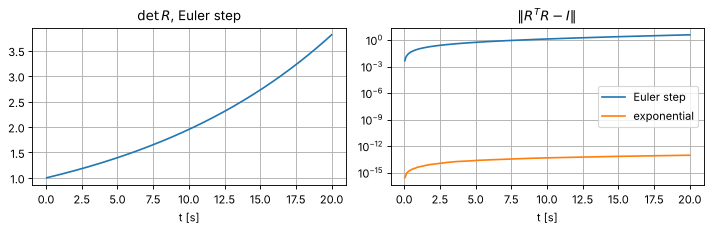

after 20 s: det(R_euler) = 3.81


In [15]:
omega, dt, steps = np.array([0.3, -0.5, 1.0]), 0.05, 400
R_exp, R_euler = np.eye(3), np.eye(3)
det_euler, orth_euler, orth_exp = [], [], []
for _ in range(steps):
    R_exp = mc.exp_so3(omega * dt) @ R_exp
    R_euler = R_euler + dt * mc.skew(omega) @ R_euler
    det_euler.append(np.linalg.det(R_euler))
    orth_euler.append(np.linalg.norm(R_euler.T @ R_euler - np.eye(3)))
    orth_exp.append(np.linalg.norm(R_exp.T @ R_exp - np.eye(3)))

fig, ax = plt.subplots(1, 2, figsize=(9, 3))
t = dt * np.arange(1, steps + 1)
ax[0].plot(t, det_euler); ax[0].set_title(r"$\det R$, Euler step"); ax[0].set_xlabel("t [s]")
ax[1].semilogy(t, orth_euler, label="Euler step")
ax[1].semilogy(t, np.maximum(orth_exp, 1e-17), label="exponential")
ax[1].set_title(r"$\|R^TR - I\|$"); ax[1].set_xlabel("t [s]"); ax[1].legend()
plt.tight_layout(); plt.show()
print(f"after {steps * dt:.0f} s: det(R_euler) = {det_euler[-1]:.2f}")

### 🔨 2. Gimbal lock

Take orientations with pitch close to $90°$ and rotate them by a tiny amount about the world $x$ axis. The
orientation changes by $10^{-3}$ rad, yet roll and yaw jump by large amounts: near the representation
singularity only $\psi - \phi$ is well defined (section 1.1).

In [16]:
delta = 1e-3
for pitch_deg in [60, 85, 89, 89.9, 89.99]:
    R0 = mc.rotation_from_rpy([0.2, np.deg2rad(pitch_deg), 0.5])
    R1 = mc.rot_x(delta) @ R0
    jump = mc.rpy_from_rotation(R1) - mc.rpy_from_rotation(R0)
    print(f"pitch {pitch_deg:6.2f}°: change in (roll, pitch, yaw) = {jump}")

pitch  60.00°: change in (roll, pitch, yaw) = [ 0.0018 -0.0005  0.0015]
pitch  85.00°: change in (roll, pitch, yaw) = [ 0.01   -0.0005  0.01  ]
pitch  89.00°: change in (roll, pitch, yaw) = [ 0.0489 -0.0005  0.0489]
pitch  89.90°: change in (roll, pitch, yaw) = [ 0.3757 -0.0006  0.3757]
pitch  89.99°: change in (roll, pitch, yaw) = [ 0.9304 -0.0009  0.9304]


### 🔨 3. The logarithm with `arccos` alone

Eq. (1.6) read literally computes $\theta = \arccos((\operatorname{tr}R - 1)/2)$. Near $\theta = \pi$ the
derivative of $\arccos$ blows up, so rounding in the trace becomes a large error in $\theta$, and dividing by
$\sin\theta$ amplifies it again. `mc.log_so3` uses $\operatorname{atan2}$ and the symmetric part instead
(section 1.4).

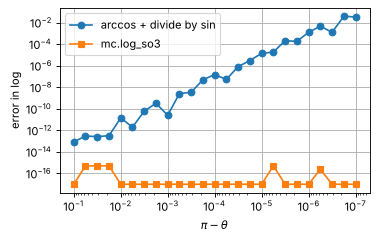

In [17]:
def log_so3_naive(R):
    theta = np.arccos(np.clip((np.trace(R) - 1) / 2, -1, 1))
    return theta / (2 * np.sin(theta)) * np.array([R[2, 1] - R[1, 2], R[0, 2] - R[2, 0], R[1, 0] - R[0, 1]])

axis = np.array([1.0, -2.0, 0.5]) / np.linalg.norm([1.0, -2.0, 0.5])
gaps = np.logspace(-1, -7, 25)  # pi - theta
err_naive = [np.linalg.norm(log_so3_naive(mc.exp_so3(axis * (np.pi - g))) - axis * (np.pi - g)) for g in gaps]
err_mc = [np.linalg.norm(mc.log_so3(mc.exp_so3(axis * (np.pi - g))) - axis * (np.pi - g)) for g in gaps]
plt.figure(figsize=(5, 3))
plt.loglog(gaps, err_naive, "o-", label="arccos + divide by sin")
plt.loglog(gaps, np.maximum(err_mc, 1e-17), "s-", label="mc.log_so3")
plt.gca().invert_xaxis(); plt.xlabel(r"$\pi - \theta$"); plt.ylabel("error in log"); plt.legend()
plt.show()

## What to remember

- Columns of $R$ are the axes of the moving frame; chain transforms so that inner indices cancel.
- Velocities of rigid bodies are twists $(v, \omega)$; the adjoint moves them between frames.
- Every displacement is a screw motion; `exp_se3` / `log_se3` convert between motion and exponential coordinates.
- Integrate rotations with the exponential, never additively.
- Euler angles are a chart with a singularity at pitch $\pm 90°$; the rotation itself has none.